# CNN Predict — ERSST Observational Inputs

Loads trained CNN models and makes slowdown predictions using **ERSSTv5 observational SST** as input.

**Figure A** — Single selected model: prediction timeline + climate indices  
**Figure B** — All models: ensemble prediction frequency + climate indices

In [1]:
import sys
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import precision_recall_curve

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from configs import paths
from src.cnn.train import load_model

2026-04-14 15:11:52.935384: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-14 15:11:52.962875: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-14 15:11:53.095911: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-14 15:11:53.095954: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-14 15:11:53.096648: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

## Configuration

Edit this cell to change which model(s) to load and which files to read.

In [2]:
# ── Model selection ──────────────────────────────────────────────────────────
N_SPLITS  = 9          # number of TVT splits trained
N_SEEDS   = 5          # random seeds per split
BASE_SEED = 42

# For Figure A: single model
SELECTED_SPLIT = 0
SELECTED_SEED  = 0

# ── File paths ────────────────────────────────────────────────────────────────
MODELS_DIR   = paths.MODELS_DIR
TESTING_FILE = paths.ERSST_TESTING          # ersstv5_testing.nc

# NSIDC observed slowdown events (September SIE)
SLOWDOWN_OBS_FILE = paths.nsidc_sie_slowdown_events(9)   # month 9 = September

# Climate indices (ERSST)
ARCTIC_SST_FILE = paths.ERSST_DIR / 'ersstv5_arctic_sst_index.nc'
NINO34_FILE     = paths.ERSST_DIR / 'ersstv5_nino34_index.nc'
ENSO_CPTP_FILE  = paths.ERSST_DIR / 'ersstv5_enso_cptp_indices.nc'
IPO_FILE        = paths.ERSST_DIR / 'ersstv5_ipo_index.nc'

# ── Threshold ─────────────────────────────────────────────────────────────────
# Default classification threshold (0.5 for sigmoid).
# Optionally recompute from training PR curve — see below.
THRESHOLD = 0.5

# ── Time ──────────────────────────────────────────────────────────────────────
OBS_START_YEAR = 1990
OBS_END_YEAR   = 2024

## Load observational testing data

In [4]:
# Load CNN-ready observation input
ds_test = xr.open_dataset(TESTING_FILE)
sst_obs = ds_test['sst'].values                  # (nyear, 192, 288) standardised + land masked
obs_years = ds_test['years'].values               # (nyear,)

# Add channel dimension for the CNN: (nyear, 192, 288, 1)
X_obs = sst_obs[..., np.newaxis].astype(np.float32)

print(f'Observation input: {X_obs.shape}  years {obs_years[0]}-{obs_years[-1]}')

Observation input: (35, 192, 288, 1)  years 1990-2024


## Load observed slowdown events (NSIDC September SIE)

In [5]:
# Observed September SIE slowdowns
ds_slow = xr.open_dataset(SLOWDOWN_OBS_FILE)
slow_years  = ds_slow['year'].values               # trend-window centre years
slow_events = ds_slow['slowdown'].values            # 1 = slowdown, 0 = normal

print(f'Observed slowdowns: {slow_events.sum()} events over {len(slow_years)} years '
      f'({slow_years[0]}-{slow_years[-1]})')

Observed slowdowns: 6 events over 26 years (1990-2015)


## Load climate indices

In [9]:
import pandas as pd
import netCDF4 as nc

# --- Arctic SST Index ---
ds_arctic = xr.open_dataset(ARCTIC_SST_FILE)
arctic_sst_monthly = ds_arctic['arctic_sst'].values     # (ntime_monthly,)
arctic_labels      = ds_arctic['labels'].values

# Build monthly date index for the full ERSST record (starts 1854-01)
nt_arctic = len(arctic_sst_monthly)
dates_arctic = pd.date_range(start='1990-01-01', periods=nt_arctic, freq='MS')

# Compute annual JJA mean for the observation window
arctic_years_mask = (dates_arctic.year >= OBS_START_YEAR) & (dates_arctic.year <= OBS_END_YEAR)
arctic_sub = arctic_sst_monthly[arctic_years_mask]
dates_sub  = dates_arctic[arctic_years_mask]
# Reshape to (nyear, 12) and take JJA (months 5:8)
n_full_years = len(arctic_sub) // 12
arctic_annual_jja = np.nanmean(
    arctic_sub[:n_full_years*12].reshape(n_full_years, 12)[:, 5:8], axis=1
)
arctic_plot_years = np.arange(OBS_START_YEAR, OBS_START_YEAR + n_full_years)

print(f'Arctic SST Index: {nt_arctic} monthly steps, '
      f'JJA annual {arctic_plot_years[0]}-{arctic_plot_years[-1]}')

# --- Nino3.4 ---
ds_nino = xr.open_dataset(NINO34_FILE)
nino34_monthly = ds_nino['nino34'].values

# --- ENSO CP/TP ---
ds_cptp = xr.open_dataset(ENSO_CPTP_FILE)
n34_monthly = ds_cptp['n34'].values
n_ct_monthly = ds_cptp['n_ct'].values
n_wp_monthly = ds_cptp['n_wp'].values

# Build date index for ENSO indices (same ERSST timeline)
nt_enso = len(n34_monthly)
dates_enso = pd.date_range(start='1854-01-01', periods=nt_enso, freq='MS')

# Compute annual JJA means for the observation window
enso_mask = (dates_enso.year >= OBS_START_YEAR) & (dates_enso.year <= OBS_END_YEAR)
n34_sub = n34_monthly[enso_mask]
nct_sub = n_ct_monthly[enso_mask]
nwp_sub = n_wp_monthly[enso_mask]
n_enso_yrs = len(n34_sub) // 12
n34_jja = np.nanmean(n34_sub[:n_enso_yrs*12].reshape(n_enso_yrs, 12)[:, 5:8], axis=1)
nct_jja = np.nanmean(nct_sub[:n_enso_yrs*12].reshape(n_enso_yrs, 12)[:, 5:8], axis=1)
nwp_jja = np.nanmean(nwp_sub[:n_enso_yrs*12].reshape(n_enso_yrs, 12)[:, 5:8], axis=1)
enso_plot_years = np.arange(OBS_START_YEAR, OBS_START_YEAR + n_enso_yrs)

print(f'ENSO CP/TP: JJA annual {enso_plot_years[0]}-{enso_plot_years[-1]}')

# --- IPO ---
ds_ipo = xr.open_dataset(IPO_FILE)
ipo_monthly  = ds_ipo['ipo'].values
ipo_filtered = ds_ipo['ipo_filtered'].values
nt_ipo = len(ipo_monthly)
dates_ipo = pd.date_range(start='1854-01-01', periods=nt_ipo, freq='MS')
ipo_mask = (dates_ipo.year >= OBS_START_YEAR) & (dates_ipo.year <= OBS_END_YEAR)
ipo_sub = ipo_filtered[ipo_mask]
n_ipo_yrs = len(ipo_sub) // 12
ipo_jja = np.nanmean(ipo_sub[:n_ipo_yrs*12].reshape(n_ipo_yrs, 12)[:, 5:8], axis=1)
ipo_plot_years = np.arange(OBS_START_YEAR, OBS_START_YEAR + n_ipo_yrs)

print(f'IPO: JJA annual {ipo_plot_years[0]}-{ipo_plot_years[-1]}')

Arctic SST Index: 428 monthly steps, JJA annual 1990-2024
ENSO CP/TP: JJA annual 1990-2024
IPO: JJA annual 1990-2024


## Load trained CNN models and run predictions

In [10]:
# Collect predictions from ALL models (all splits x all seeds)
all_probs = []     # list of (nyear,) arrays
model_ids = []     # (split_idx, run_idx) tuples

for split_idx in range(N_SPLITS):
    for run_idx in range(N_SEEDS):
        model_file = MODELS_DIR / f'cnn_jja_split{split_idx}_run{run_idx}.h5'
        if not model_file.exists():
            print(f'  [skip] {model_file.name} not found')
            continue
        model = load_model(MODELS_DIR, split_idx, run_idx)
        probs = model.predict(X_obs, verbose=0).ravel()     # (nyear,)
        all_probs.append(probs)
        model_ids.append((split_idx, run_idx))

all_probs = np.array(all_probs)    # (n_models, nyear)
print(f'Loaded {len(model_ids)} models, predictions shape: {all_probs.shape}')

2026-04-14 16:20:03.149716: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Loaded 45 models, predictions shape: (45, 35)


In [11]:
# --- Single selected model ---
sel_key = (SELECTED_SPLIT, SELECTED_SEED)
if sel_key in model_ids:
    sel_idx = model_ids.index(sel_key)
else:
    sel_idx = 0
    print(f'Selected model {sel_key} not found, falling back to {model_ids[0]}')

probs_selected = all_probs[sel_idx]                        # (nyear,)
preds_selected = (probs_selected >= THRESHOLD).astype(int)  # binary

# --- Ensemble statistics ---
preds_all = (all_probs >= THRESHOLD).astype(int)            # (n_models, nyear)
slowdown_fraction = preds_all.mean(axis=0)                  # fraction [0, 1]

print(f'Selected model: split {model_ids[sel_idx][0]}, seed {model_ids[sel_idx][1]}')
print(f'Ensemble: {len(model_ids)} models, '
      f'mean slowdown fraction = {slowdown_fraction.mean():.3f}')

Selected model: split 0, seed 0
Ensemble: 45 models, mean slowdown fraction = 0.123


---
## Figure A — Selected-Model Prediction Timeline + Climate Indices

**Panel (a)**: Prediction from one selected CNN (dashed red/gray) vs observed slowdowns (blue bars)  
**Panel (b)**: Arctic SST Index  
**Panel (c)**: Nino3.4 / CP Nino / TP Nino  
**Panel (d)**: IPO (filtered)

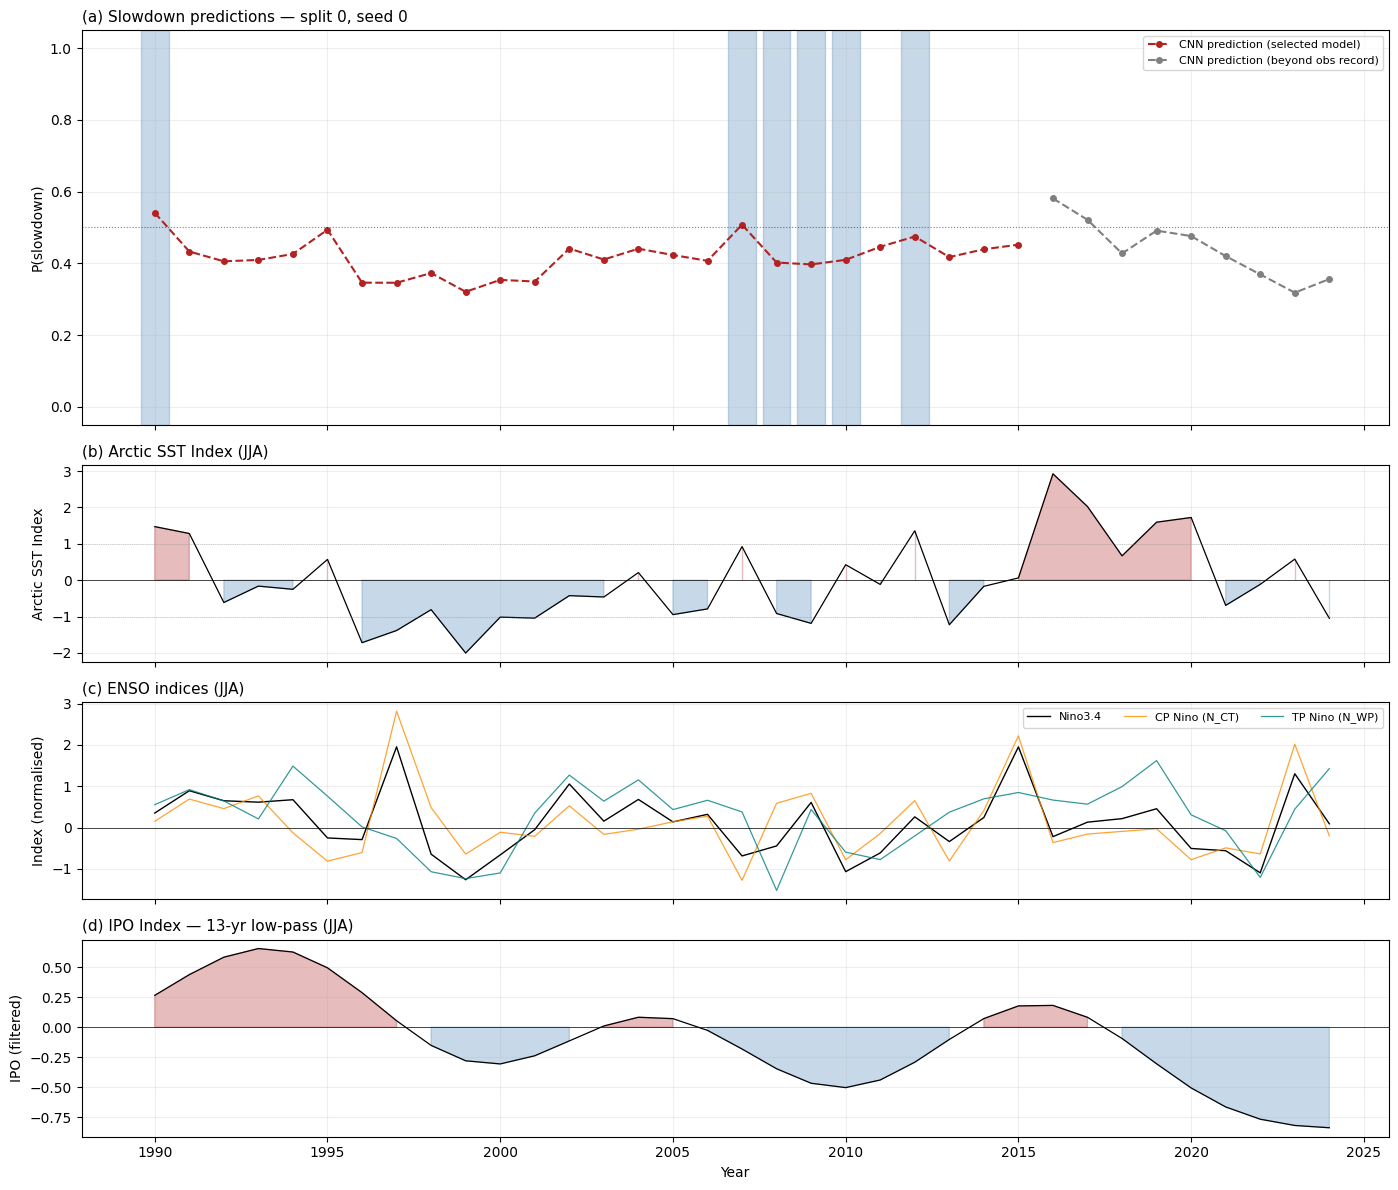

In [12]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1, 1, 1]})

# ── Panel (a): Prediction timeline ────────────────────────────────────────────
ax = axes[0]

# Observed slowdowns as background bars
for i, yr in enumerate(slow_years):
    if yr in obs_years and slow_events[i] == 1:
        ax.axvspan(yr - 0.4, yr + 0.4, color='steelblue', alpha=0.3, zorder=0)

# Predictions: red dashed where we have observations to compare,
# gray dashed for any years beyond the slowdown observation record
last_slow_year = slow_years[-1] if len(slow_years) > 0 else obs_years[-1]
mask_obs = obs_years <= last_slow_year
mask_fut = obs_years > last_slow_year

if mask_obs.any():
    ax.plot(obs_years[mask_obs], probs_selected[mask_obs],
            color='firebrick', linestyle='--', linewidth=1.5, marker='o',
            markersize=4, label='CNN prediction (selected model)', zorder=2)
if mask_fut.any():
    ax.plot(obs_years[mask_fut], probs_selected[mask_fut],
            color='gray', linestyle='--', linewidth=1.5, marker='o',
            markersize=4, label='CNN prediction (beyond obs record)', zorder=2)

ax.axhline(THRESHOLD, color='k', linestyle=':', alpha=0.5, linewidth=0.8)
ax.set_ylabel('P(slowdown)')
ax.set_ylim(-0.05, 1.05)
ax.set_title(f'(a) Slowdown predictions — split {model_ids[sel_idx][0]}, '
             f'seed {model_ids[sel_idx][1]}', loc='left', fontsize=11)
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.2)

# ── Panel (b): Arctic SST Index ──────────────────────────────────────────────
ax = axes[1]
ax.fill_between(arctic_plot_years, arctic_annual_jja, 0,
                where=(arctic_annual_jja > 0), color='firebrick', alpha=0.3)
ax.fill_between(arctic_plot_years, arctic_annual_jja, 0,
                where=(arctic_annual_jja <= 0), color='steelblue', alpha=0.3)
ax.plot(arctic_plot_years, arctic_annual_jja, color='k', linewidth=0.9)
ax.axhline(0, color='k', linewidth=0.5)
ax.axhline(1,  color='gray', linestyle=':', linewidth=0.5, alpha=0.6)
ax.axhline(-1, color='gray', linestyle=':', linewidth=0.5, alpha=0.6)
ax.set_ylabel('Arctic SST Index')
ax.set_title('(b) Arctic SST Index (JJA)', loc='left', fontsize=11)
ax.grid(True, alpha=0.2)

# ── Panel (c): Nino3.4 / CP / TP ────────────────────────────────────────────
ax = axes[2]
ax.plot(enso_plot_years, n34_jja, color='k',          linewidth=1.0, label='Nino3.4')
ax.plot(enso_plot_years, nct_jja, color='darkorange',  linewidth=0.9, label='CP Nino (N_CT)', alpha=0.8)
ax.plot(enso_plot_years, nwp_jja, color='teal',        linewidth=0.9, label='TP Nino (N_WP)', alpha=0.8)
ax.axhline(0, color='k', linewidth=0.5)
ax.set_ylabel('Index (normalised)')
ax.set_title('(c) ENSO indices (JJA)', loc='left', fontsize=11)
ax.legend(loc='upper right', fontsize=8, ncol=3)
ax.grid(True, alpha=0.2)

# ── Panel (d): IPO ──────────────────────────────────────────────────────────
ax = axes[3]
ax.fill_between(ipo_plot_years, ipo_jja, 0,
                where=(ipo_jja > 0), color='firebrick', alpha=0.3)
ax.fill_between(ipo_plot_years, ipo_jja, 0,
                where=(ipo_jja <= 0), color='steelblue', alpha=0.3)
ax.plot(ipo_plot_years, ipo_jja, color='k', linewidth=0.9)
ax.axhline(0, color='k', linewidth=0.5)
ax.set_ylabel('IPO (filtered)')
ax.set_xlabel('Year')
ax.set_title('(d) IPO Index — 13-yr low-pass (JJA)', loc='left', fontsize=11)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

---
## Figure B — Ensemble Prediction Frequency + Climate Indices

**Panel (a)**: Fraction of CNN models predicting slowdown (0-1 scale)  
**Panels (b)-(d)**: Same climate indices as Figure A

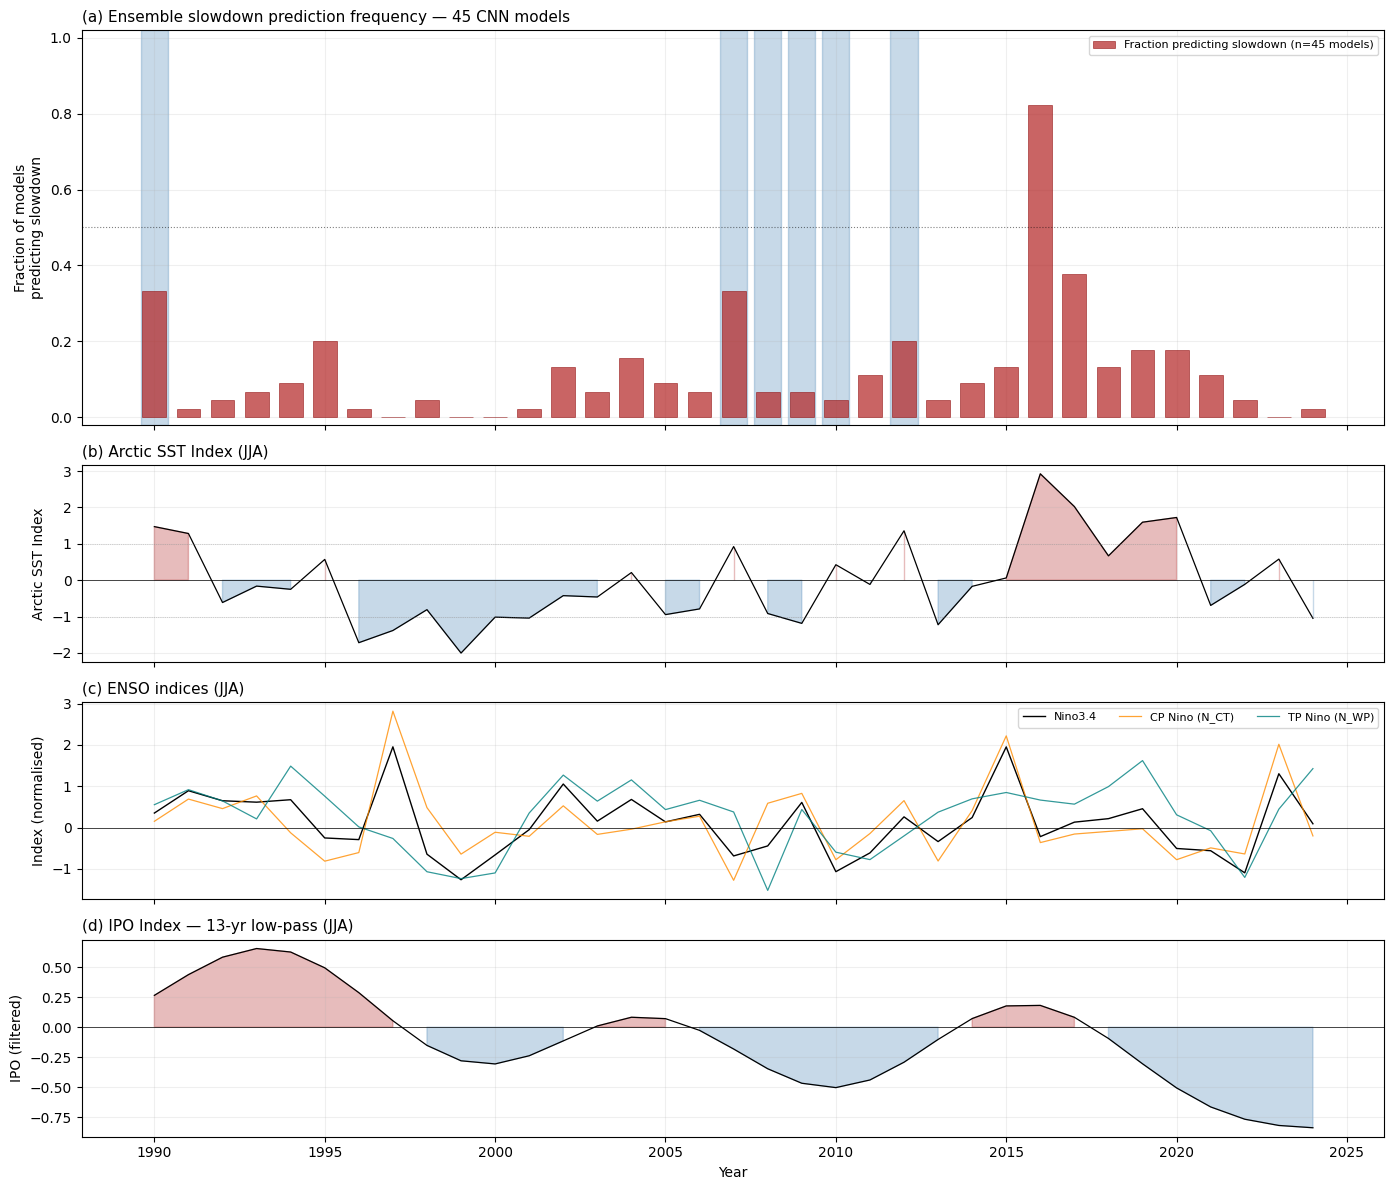

In [13]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1, 1, 1]})

# ── Panel (a): Ensemble prediction frequency ────────────────────────────────
ax = axes[0]

# Observed slowdowns as background bars
for i, yr in enumerate(slow_years):
    if yr in obs_years and slow_events[i] == 1:
        ax.axvspan(yr - 0.4, yr + 0.4, color='steelblue', alpha=0.3, zorder=0)

ax.bar(obs_years, slowdown_fraction, width=0.7,
       color='firebrick', alpha=0.7, edgecolor='darkred', linewidth=0.5,
       label=f'Fraction predicting slowdown (n={len(model_ids)} models)', zorder=2)
ax.axhline(0.5, color='k', linestyle=':', alpha=0.5, linewidth=0.8)
ax.set_ylabel('Fraction of models\npredicting slowdown')
ax.set_ylim(-0.02, 1.02)
ax.set_title(f'(a) Ensemble slowdown prediction frequency — '
             f'{len(model_ids)} CNN models', loc='left', fontsize=11)
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.2)

# ── Panel (b): Arctic SST Index ──────────────────────────────────────────────
ax = axes[1]
ax.fill_between(arctic_plot_years, arctic_annual_jja, 0,
                where=(arctic_annual_jja > 0), color='firebrick', alpha=0.3)
ax.fill_between(arctic_plot_years, arctic_annual_jja, 0,
                where=(arctic_annual_jja <= 0), color='steelblue', alpha=0.3)
ax.plot(arctic_plot_years, arctic_annual_jja, color='k', linewidth=0.9)
ax.axhline(0, color='k', linewidth=0.5)
ax.axhline(1,  color='gray', linestyle=':', linewidth=0.5, alpha=0.6)
ax.axhline(-1, color='gray', linestyle=':', linewidth=0.5, alpha=0.6)
ax.set_ylabel('Arctic SST Index')
ax.set_title('(b) Arctic SST Index (JJA)', loc='left', fontsize=11)
ax.grid(True, alpha=0.2)

# ── Panel (c): Nino3.4 / CP / TP ────────────────────────────────────────────
ax = axes[2]
ax.plot(enso_plot_years, n34_jja, color='k',          linewidth=1.0, label='Nino3.4')
ax.plot(enso_plot_years, nct_jja, color='darkorange',  linewidth=0.9, label='CP Nino (N_CT)', alpha=0.8)
ax.plot(enso_plot_years, nwp_jja, color='teal',        linewidth=0.9, label='TP Nino (N_WP)', alpha=0.8)
ax.axhline(0, color='k', linewidth=0.5)
ax.set_ylabel('Index (normalised)')
ax.set_title('(c) ENSO indices (JJA)', loc='left', fontsize=11)
ax.legend(loc='upper right', fontsize=8, ncol=3)
ax.grid(True, alpha=0.2)

# ── Panel (d): IPO ──────────────────────────────────────────────────────────
ax = axes[3]
ax.fill_between(ipo_plot_years, ipo_jja, 0,
                where=(ipo_jja > 0), color='firebrick', alpha=0.3)
ax.fill_between(ipo_plot_years, ipo_jja, 0,
                where=(ipo_jja <= 0), color='steelblue', alpha=0.3)
ax.plot(ipo_plot_years, ipo_jja, color='k', linewidth=0.9)
ax.axhline(0, color='k', linewidth=0.5)
ax.set_ylabel('IPO (filtered)')
ax.set_xlabel('Year')
ax.set_title('(d) IPO Index — 13-yr low-pass (JJA)', loc='left', fontsize=11)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()